# Healthcare Analytics for Doctor Visits

**Domain:** Healthcare

**Project Theme:** Doctor Visit Analysis

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Statsmodels, Scikit-learn

## Project Goal

This project analyzes healthcare data to understand the factors related to doctor visits and identify important patterns using data analysis, statistical methods and machine learning.

## Project Description

This project analyzes healthcare data to understand how health conditions, illness, income, insurance coverage and other factors are related to doctor visits.

## Project Objectives

- Understand the healthcare dataset.
- Clean and prepare the data.
- Explore patterns in doctor visits.
- Analyze factors related to doctor visits.
- Study relationships between healthcare variables.
- Perform statistical analysis using Poisson Regression.
- Build a Random Forest classification model.
- Evaluate the model performance.
- Identify important factors related to doctor visits.

## Dataset

The dataset contains 5,190 healthcare records and 13 variables related to doctor visits, demographic information, health conditions, income, insurance coverage and chronic conditions.

The main target variable is `visits`, which represents the number of doctor visits.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving 1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv to 1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Healthcare Analytics for Doctor Visits (1).csv to Healthcare Analytics for Doctor Visits (1).csv


In [4]:
import pandas as pd

file_name = "Healthcare Analytics for Doctor Visits (1).csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 5190
Columns: 13


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Initial Data Understanding

The dataset is first examined to understand its size, structure, variables, data types and overall quality.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5190
Number of columns: 13


In [7]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


visits
gender
age
income
illness
reduced
health
private
freepoor
freerepat
nchronic
lchronic

In [8]:
print("Columns in the dataset:")

for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Columns in the dataset:
1 - Unnamed: 0
2 - visits
3 - gender
4 - age
5 - income
6 - illness
7 - reduced
8 - health
9 - private
10 - freepoor
11 - freerepat
12 - nchronic
13 - lchronic


In [9]:
df.dtypes

,0
Unnamed: 0,int64
visits,int64
gender,object
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,object
freepoor,object


In [10]:
print("Missing values in each column:")

print(df.isnull().sum())

Missing values in each column:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64


In [11]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [12]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,"5,190.00","5,190.00","5,190.00","5,190.00","5,190.00","5,190.00","5,190.00"
mean,"2,595.50",0.30,0.41,0.58,1.43,0.86,1.22
std,"1,498.37",0.80,0.20,0.37,1.38,2.89,2.12
min,1.00,0.00,0.19,0.00,0.00,0.00,0.00
25%,"1,298.25",0.00,0.22,0.25,0.00,0.00,0.00
50%,"2,595.50",0.00,0.32,0.55,1.00,0.00,0.00
75%,"3,892.75",0.00,0.62,0.90,2.00,0.00,2.00
max,"5,190.00",9.00,0.72,1.50,5.00,14.00,12.00


## 2. Data Cleaning

The dataset is checked for duplicate records, missing values and unnecessary columns before performing further analysis.

In [13]:
# Remove unnecessary index column
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Remove duplicate records
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(duplicate_count, "duplicate records removed.")
else:
    print("No duplicate records found.")

print("Final dataset shape:", df.shape)

1320 duplicate records removed.
Final dataset shape: (3870, 12)


In [14]:
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [15]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64


## 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand patterns and relationships between doctor visits and different healthcare factors.

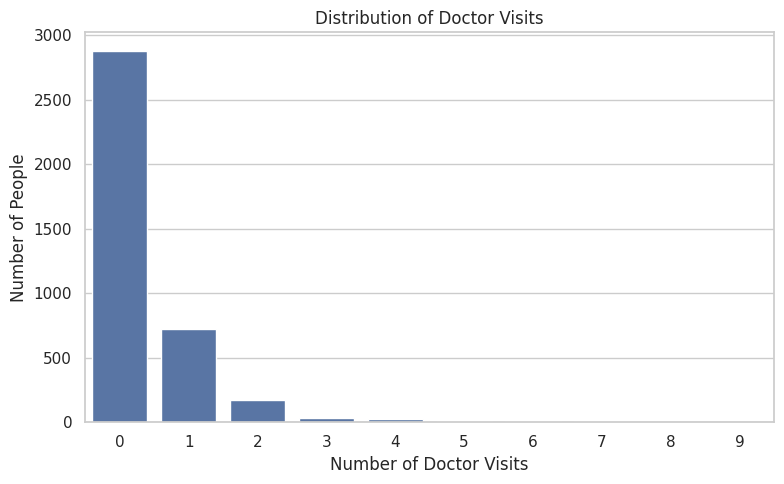

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="visits"
)

plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of People")

plt.tight_layout()
plt.show()

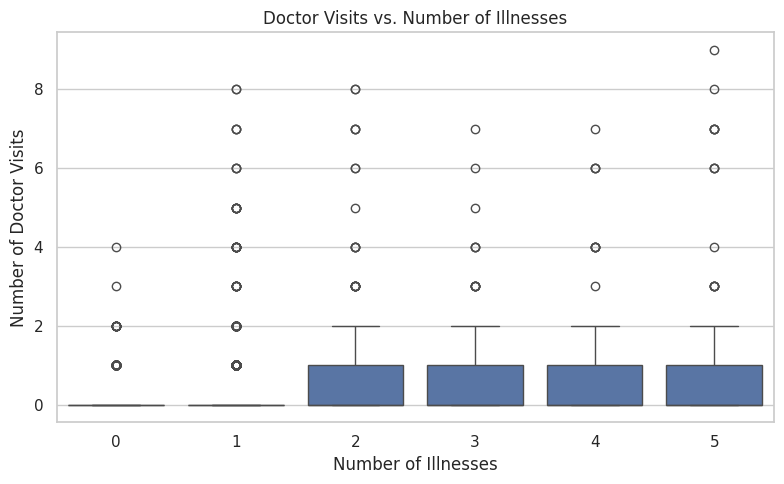

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="illness",
    y="visits"
)

plt.title("Doctor Visits vs. Number of Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Number of Doctor Visits")

plt.tight_layout()
plt.show()

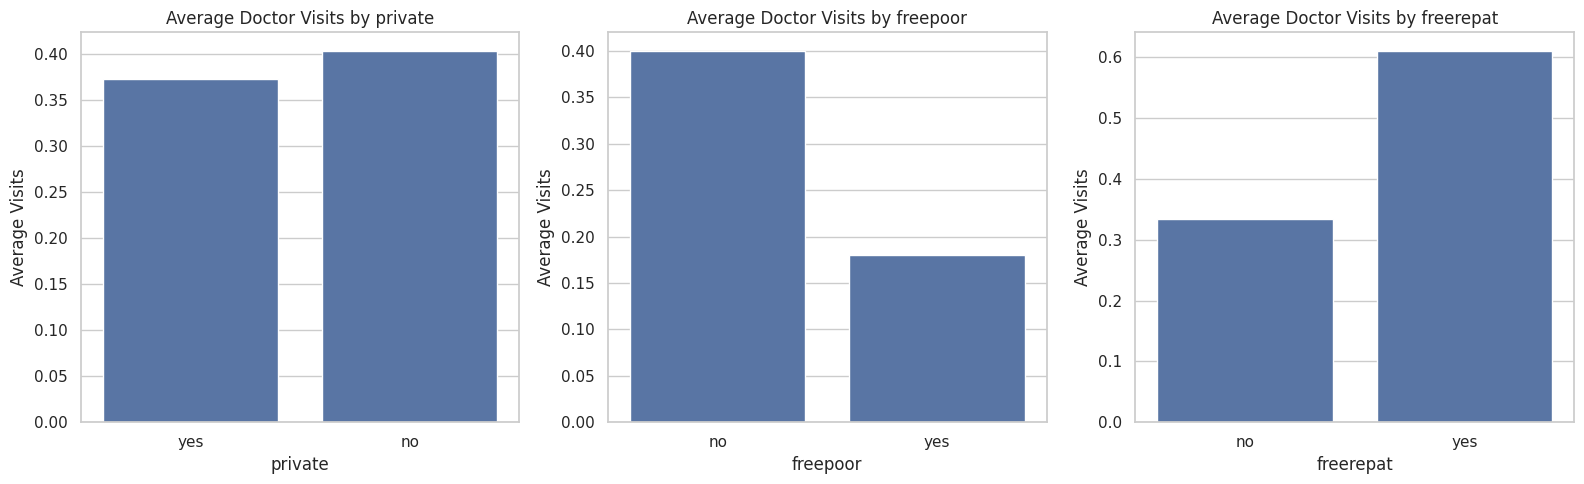

In [18]:
insurance_cols = [
    "private",
    "freepoor",
    "freerepat"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

for i, column in enumerate(insurance_cols):

    sns.barplot(
        data=df,
        x=column,
        y="visits",
        errorbar=None,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Average Doctor Visits by {column}"
    )

    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Average Visits")

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

Correlation analysis is used to examine relationships between the numerical healthcare variables.

In [19]:
df_encoded = df.copy()

binary_columns = [
    "private",
    "freepoor",
    "freerepat",
    "nchronic",
    "lchronic"
]

for column in binary_columns:
    if column in df_encoded.columns:
        df_encoded[column] = df_encoded[column].map({
            "yes": 1,
            "no": 0
        })

df_encoded["gender"] = df_encoded["gender"].map({
    "female": 1,
    "male": 0
})

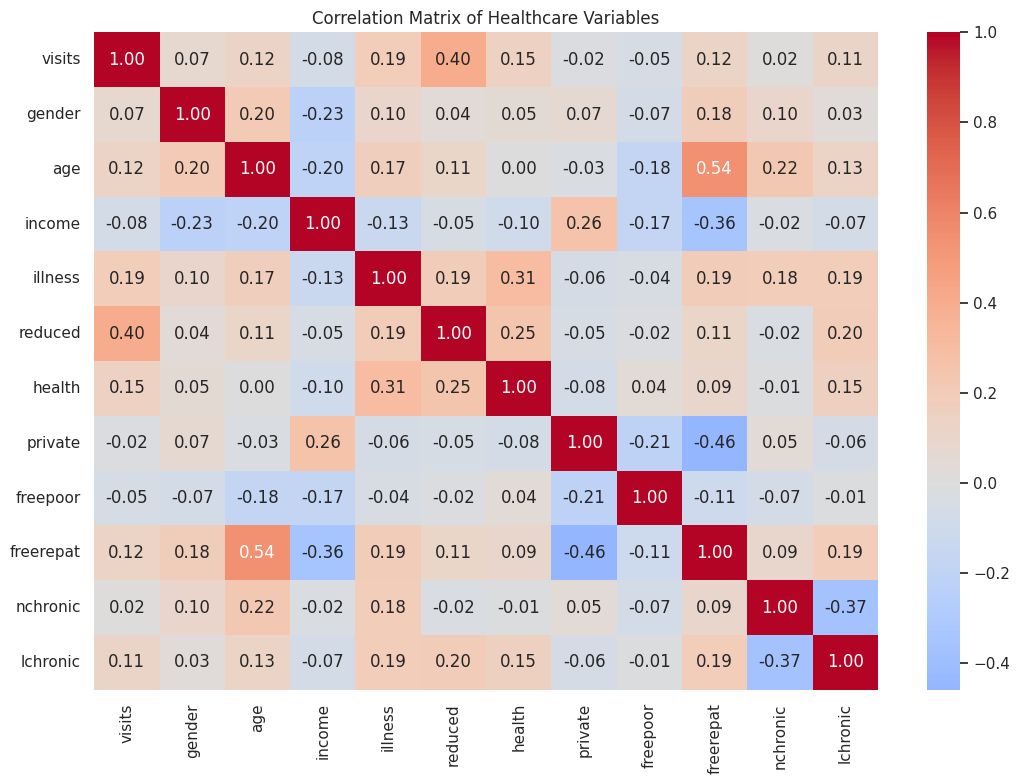

In [20]:
numeric_df = df_encoded.select_dtypes(
    include=np.number
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Healthcare Variables")

plt.tight_layout()
plt.show()

## 5. Statistical Analysis — Poisson Regression

Poisson Regression is used to examine the relationship between doctor visit counts and healthcare-related factors.

In [21]:
poisson_formula = """
visits ~ age + income + illness + reduced + health
         + gender + private + freepoor + freerepat
"""

poisson_model = smf.glm(
    formula=poisson_formula,
    data=df_encoded,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 visits   No. Observations:                 3870
Model:                            GLM   Df Residuals:                     3860
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3004.8
Date:                Tue, 22 Sep 2026   Deviance:                       3796.6
Time:                        09:39:21   Pearson chi2:                 5.31e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2127
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6883      0.102    -16.546      0.0

## 6. Machine Learning — Random Forest Classification

A Random Forest classification model is used to predict whether a person has visited a doctor or not.

- 0 = No doctor visit
- 1 = At least one doctor visit

In [22]:
df_encoded["has_visited"] = (
    df_encoded["visits"] > 0
).astype(int)

print(df_encoded["has_visited"].value_counts())

has_visited
0    2880
1     990
Name: count, dtype: int64


In [23]:
X = df_encoded.drop(
    columns=["visits", "has_visited"]
)

X = X.select_dtypes(
    include=np.number
)

y = df_encoded["has_visited"]

print("Features:")
print(X.columns.tolist())

Features:
['gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 3096
Testing records: 774


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.7261


In [27]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       576
           1       0.44      0.28      0.34       198

    accuracy                           0.73       774
   macro avg       0.61      0.58      0.58       774
weighted avg       0.69      0.73      0.70       774



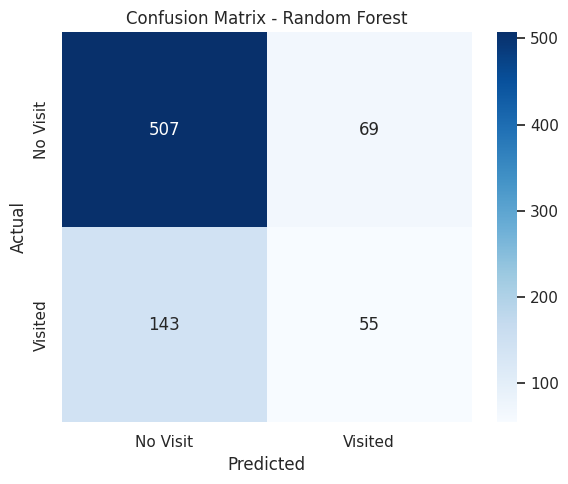

In [28]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(
        y_test,
        y_pred
    ),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Visit", "Visited"],
    yticklabels=["No Visit", "Visited"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

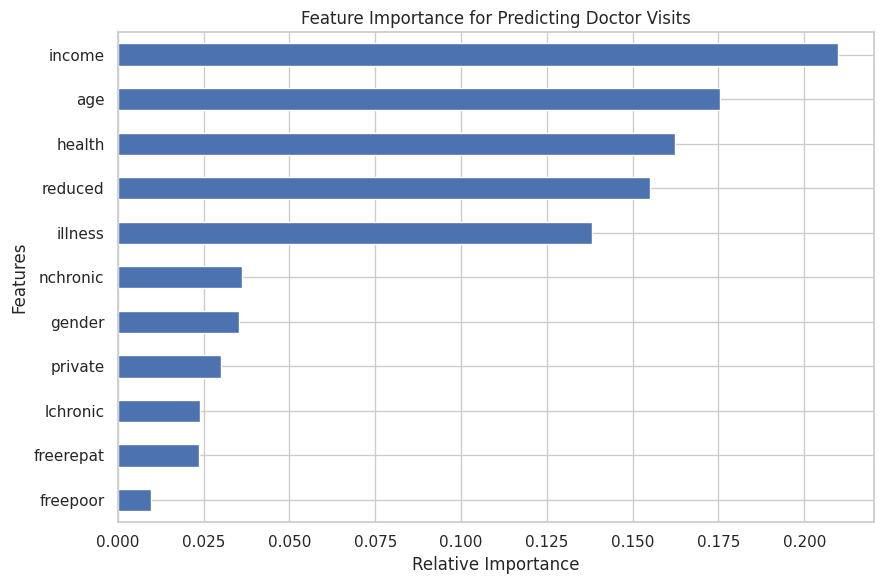

In [29]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))

feature_importances.plot(
    kind="barh"
)

plt.title(
    "Feature Importance for Predicting Doctor Visits"
)

plt.xlabel("Relative Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## 7. Key Findings

The analysis provides insights into the factors associated with doctor visits. The main findings are based on the exploratory analysis, statistical analysis and Random Forest model results.

## 8. Future Scope

- Use larger and more recent healthcare datasets.
- Include additional medical and demographic variables.
- Compare multiple machine learning algorithms.
- Improve prediction performance through feature engineering.
- Develop an interactive healthcare analytics dashboard.
- Extend the analysis to broader healthcare utilization patterns.

## 9. Conclusion

This project analyzes healthcare data to understand the factors related to doctor visits. Data cleaning, visualization, statistical analysis and machine learning were used to identify important patterns and relationships.

The analysis provides a data-based understanding of healthcare utilization and demonstrates how data analytics and machine learning can be applied to healthcare-related problems.